Fetch polling data for a given election (presidential elections for now) : 
- Quantitatively assess the relevance of opinion polling 
- Compare model predictions with opinion polling relative to the election results

In [22]:
import requests
import pandas as pd
import re
import numpy as np
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from datetime import date

In [23]:
# Get access to the data - wikipedia aggregates almost all polls in a synthetic manner. Available for recent elections
url = "https://fr.wikipedia.org/wiki/Liste_de_sondages_sur_l%27%C3%A9lection_pr%C3%A9sidentielle_fran%C3%A7aise_de_2022"
headers = {
    "User-Agent": "PollFetcher/1.0 (contact@example.com)"
}  # remplacez par vos infos
r = requests.get(url, headers=headers)
r.raise_for_status()
html = r.text

In [24]:
# Use pandas detection of tables
tables = pd.read_html(html)
soup_tables = BeautifulSoup(html, "lxml").find_all("table")

/tmp/ipykernel_4563/2381510140.py:2: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


In [4]:
store_scenario = []

In [25]:
table_dict = {}
for idx, (df, tag) in enumerate(zip(tables, soup_tables), start=1):
    # titre préféré : <caption>
    caption = tag.find("caption")
    if caption and caption.get_text(strip=True):
        title = caption.get_text(" ", strip=True)
    else:
        # sinon chercher le titre de section précédent (h1..h6)
        prev = tag.find_previous(["h1", "h2", "h3", "h4", "h5", "h6"])
        title = prev.get_text(" ", strip=True) if prev else f"table_{idx}"
    # nettoyage simple
    title = re.sub(r"\s+", " ", title).strip()
    # garantir clé unique
    key = title
    i = 1
    while key in table_dict:
        i += 1
        key = f"{title} ({i})"

    if getattr(df.columns, "nlevels", 1) > 1:
        df.columns = df.columns.get_level_values(1)

    df = df.dropna(how="all")

    df = df.copy()
    if "Date" in df.columns:
        df.rename(columns={"Date": "Dates"}, inplace=True)

    mask_rows = df.apply(lambda r: r.dropna().nunique() == 1, axis=1)
    store_scenario += (
        df[mask_rows].apply(lambda r: r.dropna().iat[0], axis=1).values
    ).tolist()
    df = df[~mask_rows].reset_index(drop=True)

    table_dict[key] = df.astype(str)

In [27]:
table_dict.keys()

dict_keys(['Sondages réalisés après la publication de la liste officielle des candidats', 'Mars 2022', 'Février 2022', 'Janvier 2022', 'Décembre 2021', 'Octobre-novembre 2021', 'Juillet-septembre 2021', 'Avril-juin 2021', 'Janvier-mars 2021', 'Années 2017-2020', 'Années 2017-2020 (2)', 'Sondages effectués après le premier tour', 'Sondages effectués avant le premier tour', 'Reports de voix', 'Sondages concernant des hypothèses abandonnées', 'Sondages concernant des hypothèses abandonnées (2)', 'Sondages concernant des hypothèses abandonnées (3)', 'Sondages concernant des hypothèses abandonnées (4)', 'Sondages concernant des hypothèses abandonnées (5)', 'Sondages concernant des hypothèses abandonnées (6)', 'Sondages concernant des hypothèses abandonnées (7)', 'Sondages concernant des hypothèses abandonnées (8)', 'Sondages concernant des hypothèses abandonnées (9)', 'Sondages concernant des hypothèses abandonnées (10)', 'Sondages concernant des hypothèses abandonnées (11)', 'Catégorie soc

Build an aggregated polls dataset. 
Key : institut_data_[opt]cat
Columns : Individual candidates (person). If the candidate is not in the poll scenario, we input a NaN values. All rows should equal to 100. 

In [6]:
poll_dataset = pd.DataFrame()
poll_dataset_t2 = pd.DataFrame()

In [7]:
def clean_numeric_percent(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.replace("\u00a0", "", regex=False).str.strip()
    is_lt = s.str.startswith("<", na=False)
    pct_mask = s.str.contains("%", na=False)

    # remove % and leading '<', normalize decimal comma
    t = s.str.replace("%", "", regex=False)
    t = t.str.replace(r"^[<\s]+", "", regex=True)
    t = t.str.replace(",", ".", regex=False)
    t = t.str.replace(r"[^\d\.\-]", "", regex=True)

    num = pd.to_numeric(t, errors="coerce")

    # wherever original value began with '<', divide that numeric value by 2
    num = num.where(~is_lt, num / 2.0)

    return num

In [8]:
for key, df in table_dict.items():
    print(f"Processing {key}")
    poll_dataset = pd.concat([poll_dataset, df], ignore_index=True)
    if key == "Décembre 2021":
        break

# Remove the Unnamed columns
print(poll_dataset)

Processing Sondages réalisés après la publication de la liste officielle des candidats
Processing Mars 2022
Processing Février 2022
Processing Janvier 2022
Processing Décembre 2021
                 Sondeur          Dates      Échantillon Arthaud (LO)  \
0              Résultats  10 avril 2022  35 132 947[N 3]       0,56 %   
1                  Ipsos        8 avril            7 321        0,5 %   
2    Harris Interractive      7-8 avril            2 113        0,5 %   
3                  Elabe      7-8 avril            1 801        0,5 %   
4             Cluster 17      6-8 avril            3 097        0,5 %   
..                   ...            ...              ...          ...   
197                Ipsos   6-8 décembre            1 500        0,5 %   
198                Elabe   6-7 décembre            1 474          1 %   
199            Cluster17   4-8 décembre            1 487        0,5 %   
200                 Ifop   4-6 décembre            1 341        0,5 %   
201   Harris Int

In [9]:
poll_dataset = poll_dataset.loc[:, ~poll_dataset.columns.str.startswith("Unnamed")]
# Reconcile columns with almosth the same name
n5_cols = poll_dataset.columns[poll_dataset.columns.str.contains(r"\[N 5\]")]
for col in n5_cols:
    matching_col = re.sub(r"\s*\[N\s*5\]\s*", " ", str(col))
    print(matching_col in poll_dataset.columns)
    idx = poll_dataset[col].dropna().index
    poll_dataset.loc[idx, matching_col] = poll_dataset.loc[idx, col].values

In [10]:
poll_dataset_t2 = pd.concat(
    [
        table_dict["Sondages effectués après le premier tour"],
        table_dict["Sondages effectués avant le premier tour"],
    ],
    ignore_index=True,
)

In [11]:
# Remove the Unnamed columns
poll_dataset = poll_dataset.loc[:, ~poll_dataset.columns.str.startswith("Unnamed")]
# Reconcile columns with almosth the same name
n5_cols = poll_dataset.columns[poll_dataset.columns.str.contains(r"\[N 5\]")]
for col in n5_cols:
    matching_col = re.sub(r"\s*\[N\s*5\]\s*", " ", str(col))
    print(matching_col in poll_dataset.columns)
    idx = poll_dataset[col].dropna().index
    poll_dataset.loc[idx, matching_col] = poll_dataset.loc[idx, col].values

In [12]:
FRENCH_MONTHS = {
    "janvier": 1,
    "février": 2,
    "fevrier": 2,
    "mars": 3,
    "avril": 4,
    "mai": 5,
    "juin": 6,
    "juillet": 7,
    "août": 8,
    "aout": 8,
    "septembre": 9,
    "octobre": 10,
    "novembre": 11,
    "décembre": 12,
    "decembre": 12,
}

SEP = r"\s*[-–—]\s*"


def _norm(s: str) -> str:
    s = s.replace("\xa0", " ").replace("\u202f", " ")
    return " ".join(s.lower().strip().split())


def _int_day(tok: str) -> int:
    tok = re.sub(r"[^\d]", "", tok)  # remove "er" and any nondigits
    return int(tok)


def reference_year_for_month(month: int) -> int:
    # previous heuristic: months < May -> year 2022 else 2021
    return 2022 if month < 5 else 2021


def parse_french_date_range(
    s: str, default_year: int | None = None
) -> tuple[date, date]:
    """
    Parse French date strings and ranges returning (start_date, end_date) as datetime.date.
    Handles:
      - single:     "8 avril" or "8 avril 2022" or "1er avril"
      - same-month: "6-8 avril" or "6 - 8 avril 2022"
      - cross-month:"31 mars - 4 avril" or "31 mars 2021 - 4 avril 2022"
    If an explicit year is present in the string it is used. If not, the function
    uses `default_year` if provided, otherwise falls back to reference_year_for_month().
    """
    if s is None:
        raise ValueError("Input is None")
    s0 = _norm(str(s))

    # cross-month range: "31 mars 2021 - 4 avril 2022" (years optional per side)
    m = re.match(
        rf"^(\d{{1,2}}(?:er)?)\s+([a-zéèêûàôùç]+)(?:\s+(\d{{4}}))?\s*{SEP}\s*(\d{{1,2}}(?:er)?)\s+([a-zéèêûàôùç]+)(?:\s+(\d{{4}}))?$",
        s0,
    )
    if m:
        d1, mon1, y1_str, d2, mon2, y2_str = m.groups()
        m1 = FRENCH_MONTHS.get(mon1)
        m2 = FRENCH_MONTHS.get(mon2)
        if not m1 or not m2:
            raise ValueError(f"Unknown month: {mon1} or {mon2}")
        y1 = (
            int(y1_str)
            if y1_str
            else (
                default_year
                if default_year is not None
                else reference_year_for_month(m1)
            )
        )
        y2 = (
            int(y2_str)
            if y2_str
            else (
                default_year
                if default_year is not None
                else reference_year_for_month(m2)
            )
        )
        # if no explicit years and month2 < month1 assume range crosses year boundary
        if (not y1_str and not y2_str) and (m2 < m1):
            # assume year2 = year1 + 1
            y2 = y1 + 1
        start = date(y1, m1, _int_day(d1))
        end = date(y2, m2, _int_day(d2))
        return end

    # same-month range: "6-8 avril 2022" or "6-8 avril"
    m = re.match(
        r"^(\d{1,2}(?:er)?)\s*[-–—]\s*(\d{1,2}(?:er)?)\s+([a-zéèêûàôùç]+)(?:\s+(\d{4}))?$",
        s0,
    )
    if m:
        d1, d2, mon, y_str = m.groups()
        mnum = FRENCH_MONTHS.get(mon)
        if not mnum:
            raise ValueError(f"Unknown month: {mon}")
        y = (
            int(y_str)
            if y_str
            else (
                default_year
                if default_year is not None
                else reference_year_for_month(mnum)
            )
        )
        start = date(y, mnum, _int_day(d1))
        end = date(y, mnum, _int_day(d2))
        if end < start:
            # assume end in next month/year
            em = mnum + 1
            ey = y
            if em > 12:
                em = 1
                ey += 1
            end = date(ey, em, _int_day(d2))
        return end

    # single date: "8 avril 2022" or "1er avril"
    m = re.match(r"^(\d{1,2}(?:er)?)\s+([a-zéèêûàôùç]+)(?:\s+(\d{4}))?$", s0)
    if m:
        d, mon, y_str = m.groups()
        mnum = FRENCH_MONTHS.get(mon)
        if not mnum:
            raise ValueError(f"Unknown month: {mon}")
        y = (
            int(y_str)
            if y_str
            else (
                default_year
                if default_year is not None
                else reference_year_for_month(mnum)
            )
        )
        dt = date(y, mnum, _int_day(d))
        return dt

    raise ValueError(f"Unrecognized date format: {s}")

In [ ]:
# Sondeur and Date
poll_dataset[["Sondeur", "Dates"]] = poll_dataset[["Sondeur", "Dates"]].astype(str)
poll_dataset.loc[poll_dataset["Sondeur"] == "Harris Interractive", "Sondeur"] = (
    "Harris Interactive"
)
poll_dataset.loc[poll_dataset["Sondeur"] == "Cluster 17", "Sondeur"] = "Cluster17"
poll_dataset.loc[poll_dataset["Sondeur"] == "Opinionway", "Sondeur"] = "OpinionWay"
poll_dataset.loc[:, "Dates_pd"] = poll_dataset.loc[:, "Dates"].apply(
    parse_french_date_range
)
poll_dataset.loc[0, "Échantillon"] = 35132947
poll_dataset["Échantillon"] = (
    poll_dataset["Échantillon"].astype(str).str.replace("\u00a0", "", regex=False)
)

In [ ]:
# Sondeur and Date
poll_dataset_t2[["Sondeur", "Dates"]] = poll_dataset_t2[["Sondeur", "Dates"]].astype(
    str
)
poll_dataset_t2.loc[poll_dataset_t2["Sondeur"] == "Harris Interractive", "Sondeur"] = (
    "Harris Interactive"
)
poll_dataset_t2.loc[poll_dataset_t2["Sondeur"] == "Cluster 17", "Sondeur"] = "Cluster17"
poll_dataset_t2.loc[poll_dataset_t2["Sondeur"] == "Opinionway", "Sondeur"] = (
    "OpinionWay"
)
poll_dataset_t2.loc[:, "Dates_pd"] = poll_dataset_t2.loc[:, "Dates"].apply(
    parse_french_date_range
)
poll_dataset_t2.loc[0, "Échantillon"] = 32077401
poll_dataset_t2["Échantillon"] = (
    poll_dataset_t2["Échantillon"].astype(str).str.replace("\u00a0", "", regex=False)
)

In [ ]:
# Results
for col in poll_dataset.columns:
    if col not in ["Sondeur", "Dates", "Échantillon", "Dates_pd"]:
        poll_dataset[col] = clean_numeric_percent(poll_dataset[col])

In [ ]:
# Results
for col in poll_dataset_t2.columns:
    if col not in ["Sondeur", "Dates", "Échantillon", "Dates_pd"]:
        poll_dataset_t2[col] = clean_numeric_percent(poll_dataset_t2[col])

In [ ]:
# We consider all other candidates as "Autres"
CANDIDATES = [
    "Arthaud (LO)",
    "Poutou (NPA)",
    "Roussel (PCF)",
    "Mélenchon (LFI)",
    "Hidalgo (PS)",
    "Jadot (EÉLV)",
    "Macron (LREM)",
    "Pécresse (LR)",
    "Lassalle (RES)",
    "Dupont-Aignan (DLF)",
    "Le Pen (RN)",
    "Zemmour (REC)",
]

CANDIDATES_T2 = ["Macron (LREM)", "Le Pen (RN)"]

In [ ]:
not_candidate_cols = list(
    set(poll_dataset.columns)
    - set(CANDIDATES + ["Dates", "Dates_pd", "Échantillon", "Sondeur", "Autres"])
)

In [ ]:
poll_dataset["Autres"] = poll_dataset[not_candidate_cols].sum(axis=1)
poll_dataset.drop(
    columns=[c for c in not_candidate_cols if c in poll_dataset.columns], inplace=True
)

In [ ]:
poll_dataset

,Sondeur,Dates,Échantillon,Arthaud (LO),Poutou (NPA),Roussel (PCF),Mélenchon (LFI),Hidalgo (PS),Jadot (EÉLV),Macron (LREM),Pécresse (LR),Lassalle (RES),Dupont-Aignan (DLF),Le Pen (RN),Zemmour (REC),Autres,Dates_pd
0,Résultats,10 avril 2022,35132947,0.56,0.77,2.28,21.95,1.75,4.63,27.85,4.78,3.13,2.06,23.15,7.07,0.00,2022-04-10
1,Ipsos,8 avril,7321,0.50,1.00,3.00,17.50,2.00,5.00,26.50,8.50,2.00,2.50,22.50,9.00,0.00,2022-04-08
2,Harris Interactive,7-8 avril,2113,0.50,1.00,2.50,18.00,2.00,4.50,27.00,8.00,2.00,2.00,24.00,8.50,0.00,2022-04-08
3,Elabe,7-8 avril,1801,0.50,1.00,2.50,17.50,2.00,4.00,26.00,8.00,2.50,2.50,25.00,8.50,0.00,2022-04-08
4,Cluster17,6-8 avril,3097,0.50,1.00,2.50,18.00,2.00,4.00,26.00,9.50,3.00,3.00,21.00,9.50,0.00,2022-04-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,Ipsos,6-8 décembre,1500,0.50,1.50,2.00,8.00,5.00,7.00,25.00,16.00,1.00,1.50,16.00,14.00,2.50,2021-12-08
198,Elabe,6-7 décembre,1474,1.00,2.00,1.00,8.00,3.00,7.00,23.00,20.00,2.00,2.00,15.00,14.00,3.50,2021-12-07
199,Cluster17,4-8 décembre,1487,0.50,1.00,2.00,13.00,3.00,5.00,23.00,16.00,1.00,2.00,16.00,15.00,2.50,2021-12-08
200,Ifop,4-6 décembre,1341,0.50,0.50,2.50,9.00,5.00,6.00,25.00,17.00,0.50,2.50,17.00,13.00,1.50,2021-12-06


In [ ]:
poll_dataset[CANDIDATES].sum(axis=1).mean()

np.float64(98.13678217821781)

In [ ]:
poll_dataset_t2[CANDIDATES_T2].sum(axis=1).mean()

np.float64(100.0)

## Appliquer les blocs politique de Pikety et Cage

In [ ]:
election_2022 = pd.read_parquet(
    "/home/onyxia/work/election_modeling_uhcp/data/raw/elections/presidentiel/2022/pres2022_csv/pres2022comm.parquet"
)

In [ ]:
election_2022[
    [
        "pvoixARTHAUD",
        "pvoixPOUTOU",
        "pvoixROUSSEL",
        "pvoixMELENCHON",
        "pvoixJADOT",
        "pvoixHIDALGO",
        "pvoixLASSALLE",
        "pvoixMACRON",
        "pvoixPECRESSE",
        "pvoixZEMMOUR",
        "pvoixDUPONTAIGNAN",
        "pvoixMLEPEN",
    ]
].mean().sum()

np.float64(1.000000002580208)

In [ ]:
election_2022[["pvoteG", "pvoteCG", "pvoteC", "pvoteCD", "pvoteD"]].mean().sum()

np.float64(1.000000000153919)

In [ ]:
blocs = {
    "G": ["Arthaud (LO)", "Poutou (NPA)", "Roussel (PCF)", "Mélenchon (LFI)"],
    "CG": [
        "Hidalgo (PS)",
        "Jadot (EÉLV)",
    ],
    "C": ["Macron (LREM)"],
    "CD": [
        "Pécresse (LR)",
    ],
    "D": ["Dupont-Aignan (DLF)", "Le Pen (RN)", "Zemmour (REC)"],
}

blocs_1 = ["G", "CG", "CD", "C", "D"]
bloc_2 = ["GCG", "DCD", "C_"]
bloc_3 = ["TG", "TD"]

In [ ]:
for bloc, canditates in blocs.items():
    poll_dataset[bloc] = poll_dataset[canditates].sum(axis=1)

poll_dataset["GCG"] = poll_dataset["G"] + poll_dataset["CG"] / 2
poll_dataset["C_"] = (
    poll_dataset["C"] + +poll_dataset["CG"] / 2 + +poll_dataset["CD"] / 2
)
poll_dataset["DCD"] = poll_dataset["D"] + poll_dataset["CD"] / 2
poll_dataset["TG"] = poll_dataset["G"] + poll_dataset["CG"] + poll_dataset["C"] / 2
poll_dataset["TD"] = poll_dataset["D"] + poll_dataset["CD"] + poll_dataset["C"] / 2
poll_dataset["validation_2"] = poll_dataset[list(blocs.keys())].sum(axis=1)
poll_dataset["validation_3"] = poll_dataset[bloc_2].sum(axis=1)
poll_dataset["validation_3"] = poll_dataset[bloc_3].sum(axis=1)

In [ ]:
poll_dataset

,Sondeur,Dates,Échantillon,Arthaud (LO),Poutou (NPA),Roussel (PCF),Mélenchon (LFI),Hidalgo (PS),Jadot (EÉLV),Macron (LREM),...,C,CD,D,GCG,C_,DCD,TG,TD,validation_2,validation_3
0,Résultats,10 avril 2022,35132947,0.56,0.77,2.28,21.95,1.75,4.63,27.85,...,27.85,4.78,32.28,28.75,33.43,34.67,45.865,50.985,96.85,96.85
1,Ipsos,8 avril,7321,0.50,1.00,3.00,17.50,2.00,5.00,26.50,...,26.50,8.50,34.00,25.50,34.25,38.25,42.250,55.750,98.00,98.00
2,Harris Interactive,7-8 avril,2113,0.50,1.00,2.50,18.00,2.00,4.50,27.00,...,27.00,8.00,34.50,25.25,34.25,38.50,42.000,56.000,98.00,98.00
3,Elabe,7-8 avril,1801,0.50,1.00,2.50,17.50,2.00,4.00,26.00,...,26.00,8.00,36.00,24.50,33.00,40.00,40.500,57.000,97.50,97.50
4,Cluster17,6-8 avril,3097,0.50,1.00,2.50,18.00,2.00,4.00,26.00,...,26.00,9.50,33.50,25.00,33.75,38.25,41.000,56.000,97.00,97.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,Ipsos,6-8 décembre,1500,0.50,1.50,2.00,8.00,5.00,7.00,25.00,...,25.00,16.00,31.50,18.00,39.00,39.50,36.500,60.000,96.50,96.50
198,Elabe,6-7 décembre,1474,1.00,2.00,1.00,8.00,3.00,7.00,23.00,...,23.00,20.00,31.00,17.00,38.00,41.00,33.500,62.500,96.00,96.00
199,Cluster17,4-8 décembre,1487,0.50,1.00,2.00,13.00,3.00,5.00,23.00,...,23.00,16.00,33.00,20.50,35.00,41.00,36.000,60.500,96.50,96.50
200,Ifop,4-6 décembre,1341,0.50,0.50,2.50,9.00,5.00,6.00,25.00,...,25.00,17.00,32.50,18.00,39.00,41.00,36.000,62.000,98.00,98.00


## Analyse des sondages

In [ ]:
y_true = poll_dataset.loc[0, CANDIDATES].values
y_pred = poll_dataset.loc[1:, CANDIDATES].values
y_true_bcast = np.broadcast_to(y_true, y_pred.shape)
diff = y_pred - y_true_bcast

In [ ]:
y_true_t2 = poll_dataset_t2.loc[0, CANDIDATES_T2].values
y_pred_t2 = poll_dataset_t2.loc[1:, CANDIDATES_T2].values
y_true_t2_bcast = np.broadcast_to(y_true_t2, y_pred_t2.shape)
diff_t2 = y_pred_t2 - y_true_t2_bcast

In [ ]:
y_true_b = poll_dataset.loc[0, bloc_3].values
y_pred_b = poll_dataset.loc[1:, bloc_3].values
y_true_b_bcast = np.broadcast_to(y_true_b, y_pred_b.shape)
biais = np.abs((y_pred_b[:, 0] - y_true_b_bcast[:, 0])) - np.abs(
    (y_pred_b[:, 1] - y_true_b_bcast[:, 1])
)

In [ ]:
poll_dataset.loc[1:, "mse"] = np.nanmean(diff**2, axis=1)
poll_dataset.loc[1:, "rmse"] = np.sqrt(
    np.sqrt(np.asarray(np.nanmean(diff**2, axis=1), dtype=float))
)
poll_dataset.loc[1:, "mae"] = np.nanmean(np.abs(diff), axis=1)
poll_dataset.loc[1:, "biais"] = biais

denom = np.where(y_true_bcast == 0, np.nan, y_true_bcast)
poll_dataset.loc[1:, "mape"] = np.nanmean(np.abs(diff / denom), axis=1) * 100.0

In [ ]:
poll_dataset_t2.loc[1:, "mse"] = np.nanmean(diff_t2**2, axis=1)
poll_dataset_t2.loc[1:, "rmse"] = np.sqrt(
    np.sqrt(np.asarray(np.nanmean(diff_t2**2, axis=1), dtype=float))
)
poll_dataset_t2.loc[1:, "mae"] = np.nanmean(np.abs(diff_t2), axis=1)

denom = np.where(y_true_t2_bcast == 0, np.nan, y_true_t2_bcast)
poll_dataset_t2.loc[1:, "mape"] = np.nanmean(np.abs(diff_t2 / denom), axis=1) * 100.0

Quel sondeur est le meilleur?

In [ ]:
F1 = (
    poll_dataset.loc[1:100, ["Sondeur", "rmse", "mae", "biais"]]
    .groupby("Sondeur")
    .mean()
)

In [ ]:
F2 = poll_dataset_t2.loc[1:100, ["Sondeur", "rmse", "mae"]].groupby("Sondeur").mean()

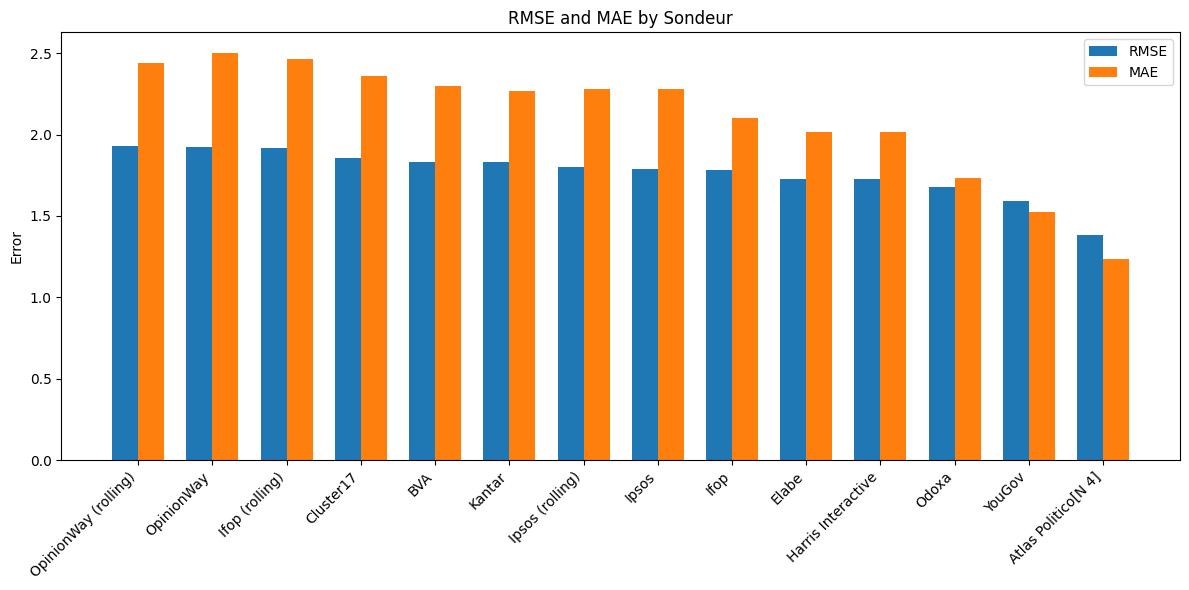

In [ ]:
# F1: DataFrame indexed by Sondeur with columns 'rmse' and 'mae'
df = F1.copy()

# drop rows where both metrics are NA (e.g. the "truth" row)
df = df.dropna(subset=["rmse", "mae"], how="all")

# optional: sort (choose 'rmse' or 'mae' or None)
df = df.sort_values("rmse", ascending=False)

labels = df.index.astype(str)
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width / 2, df["rmse"], width, label="RMSE", color="C0")
bars2 = ax.bar(x + width / 2, df["mae"], width, label="MAE", color="C1")

# format x ticks
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")

# labels, legend, layout
ax.set_ylabel("Error")
ax.set_title("RMSE and MAE by Sondeur")
ax.legend()
plt.tight_layout()
plt.show()

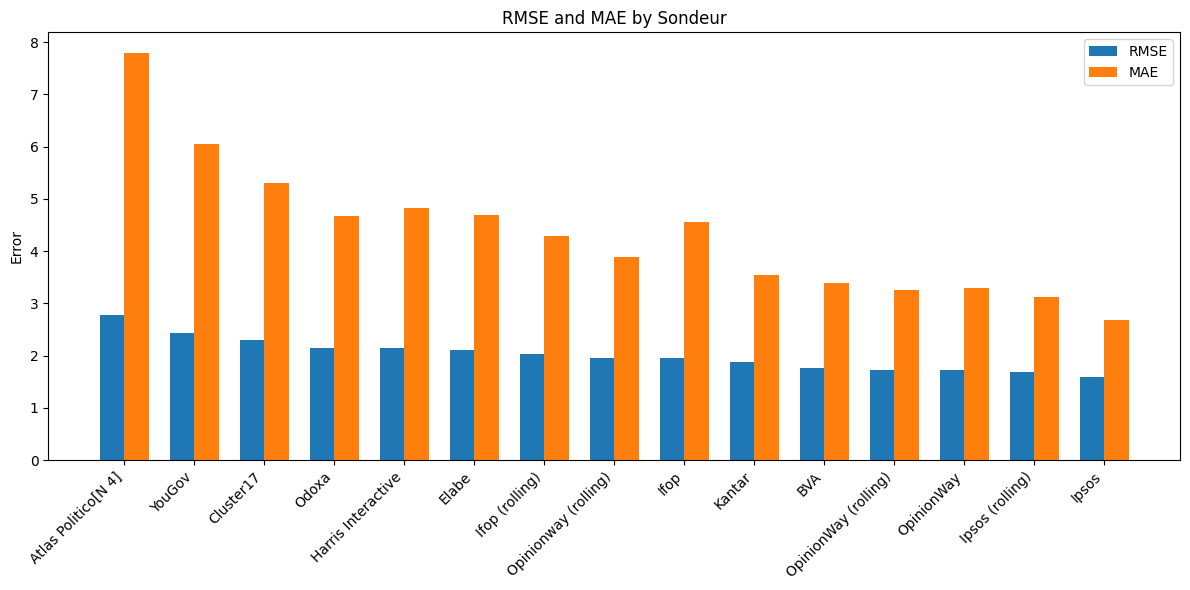

In [ ]:
# F1: DataFrame indexed by Sondeur with columns 'rmse' and 'mae'
df = F2.copy()

# drop rows where both metrics are NA (e.g. the "truth" row)
df = df.dropna(subset=["rmse", "mae"], how="all")

# optional: sort (choose 'rmse' or 'mae' or None)
df = df.sort_values("rmse", ascending=False)

labels = df.index.astype(str)
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width / 2, df["rmse"], width, label="RMSE", color="C0")
bars2 = ax.bar(x + width / 2, df["mae"], width, label="MAE", color="C1")

# format x ticks
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")

# labels, legend, layout
ax.set_ylabel("Error")
ax.set_title("RMSE and MAE by Sondeur")
ax.legend()
plt.tight_layout()
plt.show()

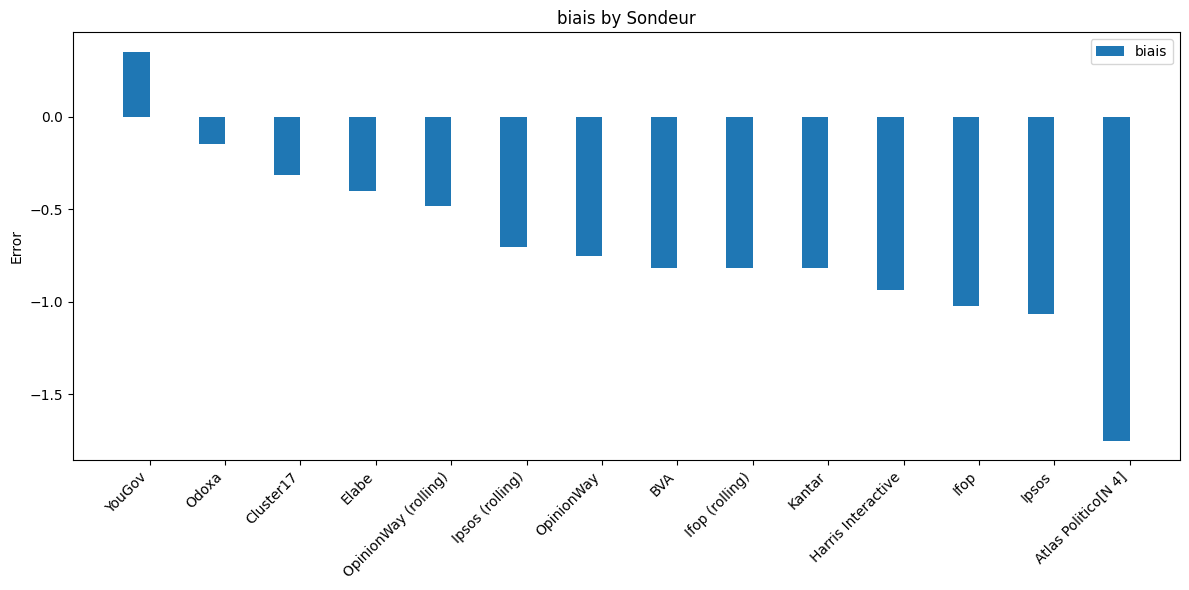

In [ ]:
# F1: DataFrame indexed by Sondeur with columns 'rmse' and 'mae'
df = F1.copy()

# drop rows where both metrics are NA (e.g. the "truth" row)
df = df.dropna(subset=["biais"], how="all")

# optional: sort (choose 'rmse' or 'mae' or None)
df = df.sort_values("biais", ascending=False)

labels = df.index.astype(str)
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width / 2, df["biais"], width, label="biais", color="C0")

# format x ticks
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")

# labels, legend, layout
ax.set_ylabel("Error")
ax.set_title("biais by Sondeur")
ax.legend()
plt.tight_layout()
plt.show()

Quel est l'impact de la taille de l'échantillon?

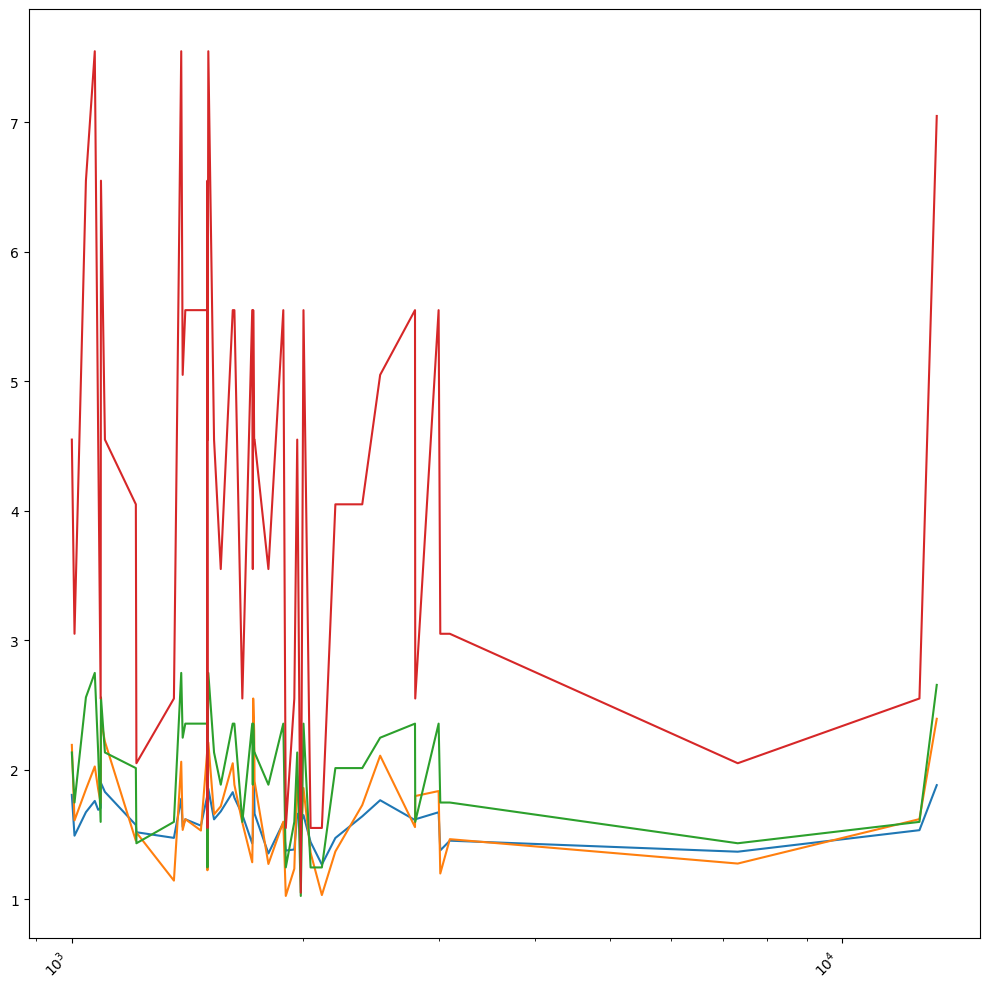

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
x = pd.to_numeric(poll_dataset.loc[1:50, "Échantillon"], errors="coerce")
y = pd.to_numeric(poll_dataset.loc[1:50, "rmse"], errors="coerce")
y_ = pd.to_numeric(poll_dataset.loc[1:50, "mae"], errors="coerce")
y_t2 = pd.to_numeric(poll_dataset_t2.loc[1:50, "rmse"], errors="coerce")
y_t2_ = pd.to_numeric(poll_dataset_t2.loc[1:50, "mae"], errors="coerce")
df = pd.DataFrame({"x": x, "y": y, "y_": y_, "y_t2": y_t2, "y_t2_": y_t2_}).dropna()
df = df.sort_values("x", ascending=True)
plt.plot(df["x"], df["y"])
plt.plot(df["x"], df["y_"])
plt.plot(df["x"], df["y_t2"])
plt.plot(df["x"], df["y_t2_"])
plt.xscale("log")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

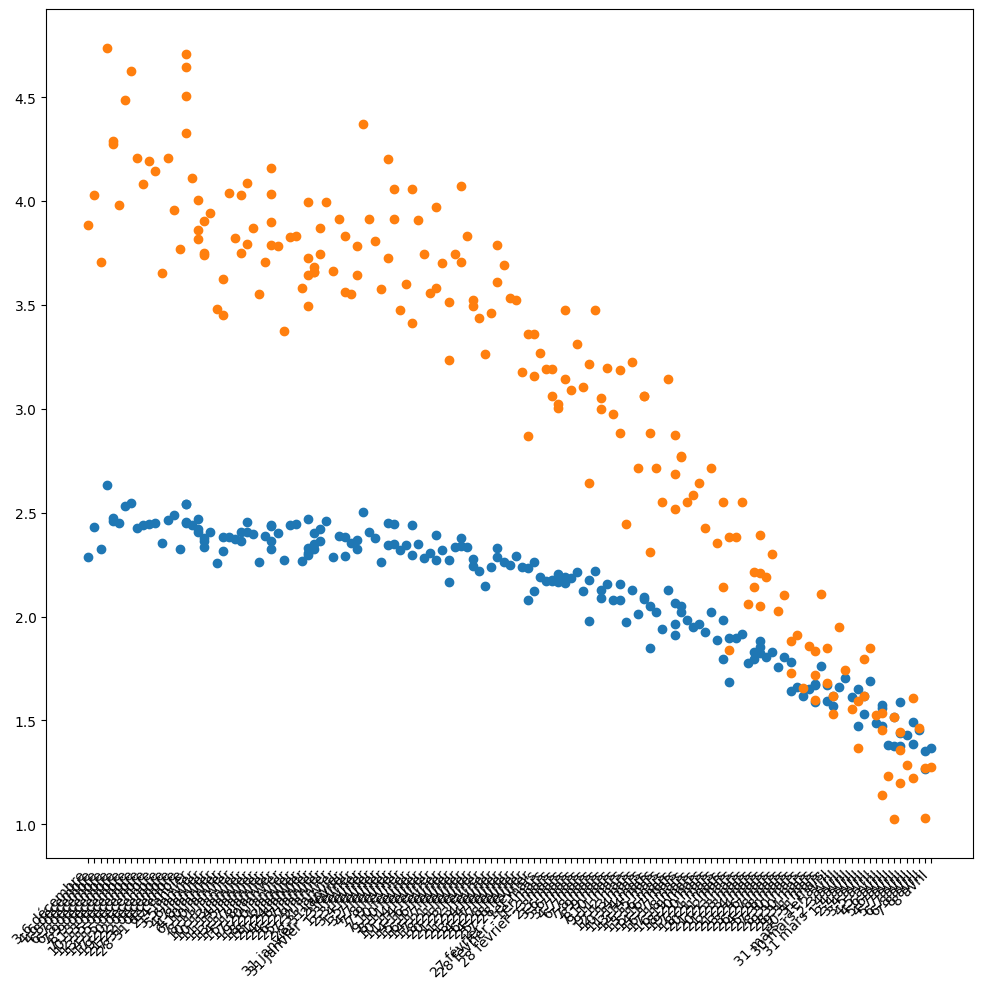

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.scatter(poll_dataset.loc[1:, "Dates"][::-1], poll_dataset.loc[1:, "rmse"][::-1])
plt.scatter(poll_dataset.loc[1:, "Dates"][::-1], poll_dataset.loc[1:, "mae"][::-1])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

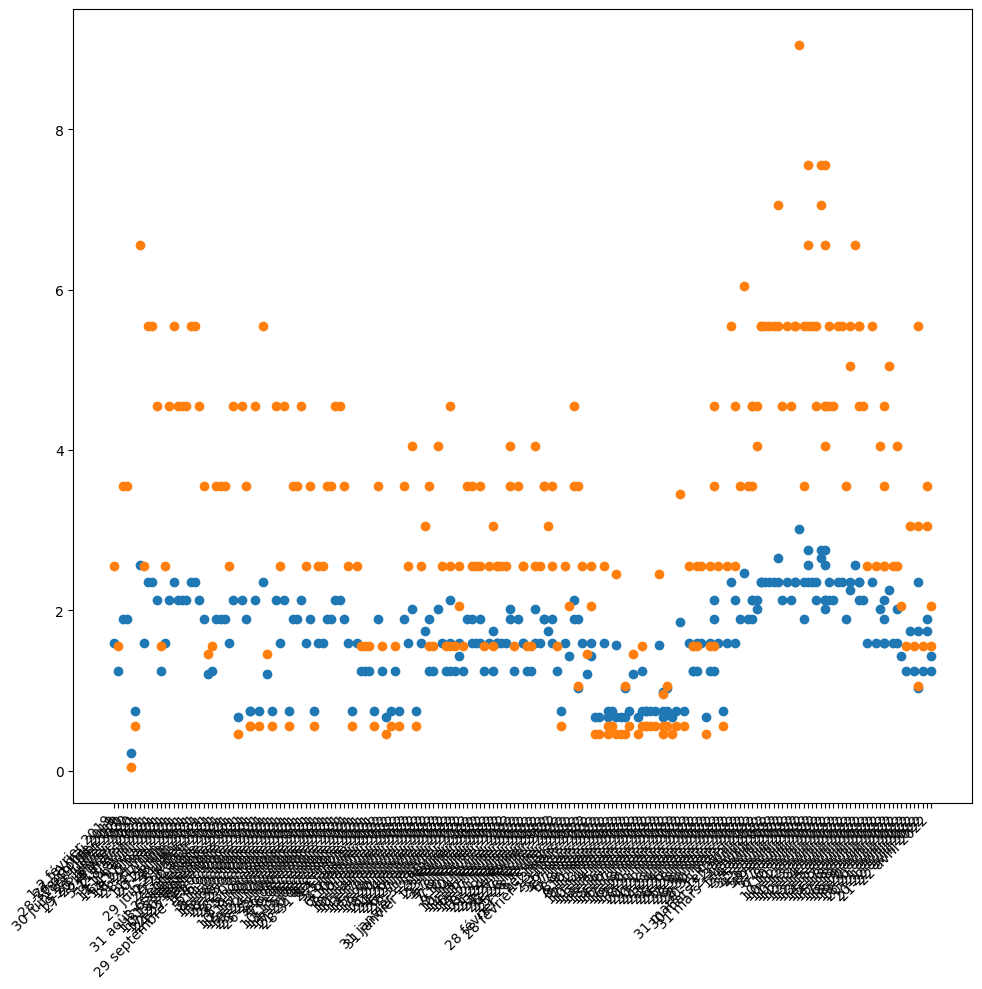

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.scatter(
    poll_dataset_t2.loc[1:, "Dates"][::-1], poll_dataset_t2.loc[1:, "rmse"][::-1]
)
plt.scatter(
    poll_dataset_t2.loc[1:, "Dates"][::-1], poll_dataset_t2.loc[1:, "mae"][::-1]
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
poll_dataset.columns

Index(['Sondeur', 'Dates', 'Échantillon', 'Arthaud (LO)', 'Poutou (NPA)',
       'Roussel (PCF)', 'Mélenchon (LFI)', 'Hidalgo (PS)', 'Jadot (EÉLV)',
       'Macron (LREM)', 'Pécresse (LR)', 'Lassalle (RES)',
       'Dupont-Aignan (DLF)', 'Le Pen (RN)', 'Zemmour (REC)', 'Autres',
       'Dates_pd', 'G', 'CG', 'C', 'CD', 'D', 'GCG', 'C_', 'DCD', 'TG', 'TD',
       'validation_2', 'validation_3', 'mse', 'rmse', 'mae', 'biais', 'mape'],
      dtype='object')

In [ ]:
poll_dataset_t2

,Sondeur,Dates,Échantillon,Macron (LREM),Le Pen (RN),Dates_pd,mse,rmse,mae,mape
0,Résultats,24 avril 2022,32077401,58.55,41.45,2022-04-24,NaN,NaN,NaN,NaN
1,Ipsos,22 avril 2022,12129,56.50,43.50,2022-04-22,4.2025,1.431782,2.05,4.223499
2,Ipsos,22 avril 2022,1600,57.00,43.00,2022-04-22,2.4025,1.244990,1.55,3.193378
3,Harris Interactive,21-22 avril 2022,2379,55.00,45.00,2022-04-22,12.6025,1.884144,3.55,7.313865
4,Elabe,21-22 avril 2022,1800,55.50,44.50,2022-04-22,9.3025,1.746425,3.05,6.283743
...,...,...,...,...,...,...,...,...,...,...
247,Elabe,30 juin-1er juillet 2020,1002,58.50,41.50,2020-07-01,0.0025,0.223607,0.05,0.103012
248,Ifop,18-19 juin 2020,992,55.00,45.00,2020-06-19,12.6025,1.884144,3.55,7.313865
249,Ifop,28-30 octobre 2019,1396,55.00,45.00,2019-10-30,12.6025,1.884144,3.55,7.313865
250,Ifop,27-28 mai 2019,927,57.00,43.00,2019-05-28,2.4025,1.244990,1.55,3.193378


## Nsppolls data 

In [ ]:
df = pd.read_json(
    "/home/onyxia/work/election_modeling_uhcp/notebooks/polls/presidentielle.json"
)

In [ ]:
# Collect premier tours results for candidate that actually ran in the election
true_candidates = [
    "Nathalie Arthaud",
    "Philippe Poutou",
    "Fabien Roussel",
    "Jean-Luc Mélenchon",
    "Anne Hidalgo",
    "Yannick Jadot",
    "Emmanuel Macron",
    "Valérie Pécresse",
    "Jean Lassalle",
    "Nicolas Dupont-Aignan",
    "Marine Le Pen",
    "Eric Zemmour",
]
k = 0
n = len(df)
dfextended = df.copy(deep=True)
for index, row in df.iterrows():
    if index > len(df):
        break
    print(index, n)
    # Premier tours, première hypothèse
    tour = df["tours"].iloc[index][0][
        "tour"
    ]  # ['hypotheses'][0]['candidats'][0]['candidat']
    if tour == "Premier tour":
        for j in range(len(df["tours"].iloc[index][0]["hypotheses"])):
            candidats_nb = len(df["tours"].iloc[index][0]["hypotheses"][j]["candidats"])
            df.loc[index, "sous_echantillon"] = df["tours"].iloc[index][0][
                "hypotheses"
            ][j]["sous_echantillon"]
            for i in range(candidats_nb):
                cand = df["tours"].iloc[index][0]["hypotheses"][j]["candidats"][i][
                    "candidat"
                ]
                parti = df["tours"].iloc[index][0]["hypotheses"][j]["candidats"][i][
                    "parti"
                ][0]
                if (cand not in true_candidates) or (cand is None):
                    cand = "Autres"
                intention = df["tours"].iloc[index][0]["hypotheses"][j]["candidats"][i][
                    "intentions"
                ]
                intention_sup = df["tours"].iloc[index][0]["hypotheses"][j][
                    "candidats"
                ][i]["erreur_sup"]
                intention_inf = df["tours"].iloc[index][0]["hypotheses"][j][
                    "candidats"
                ][i]["erreur_inf"]
                if j == 1:
                    dfextended.loc[index, f"{cand}"] = intention
                # else:
                #    dfextended.loc[len(df)+k, :] = df.loc[index, :]
                #    dfextended.loc[len(df)+k, f'{cand}'] = intention
                #    k+=1
                # df.loc[index, f'{cand} sup'] = intention_sup
                # df.loc[index, f'{cand} inf'] = intention_inf

0 409
1 409
2 409
3 409
4 409
5 409
6 409
7 409
8 409
9 409
10 409
11 409
12 409
13 409
14 409
15 409
16 409
17 409
18 409
19 409
20 409
21 409
22 409
23 409
24 409
25 409
26 409
27 409
28 409
29 409
30 409
31 409
32 409
33 409
34 409
35 409
36 409
37 409
38 409
39 409
40 409
41 409
42 409
43 409
44 409
45 409
46 409
47 409
48 409
49 409
50 409
51 409
52 409
53 409
54 409
55 409
56 409
57 409
58 409
59 409
60 409
61 409
62 409
63 409
64 409
65 409
66 409
67 409
68 409
69 409
70 409
71 409
72 409
73 409
74 409
75 409
76 409
77 409
78 409
79 409
80 409
81 409
82 409
83 409
84 409
85 409
86 409
87 409
88 409
89 409
90 409
91 409
92 409
93 409
94 409
95 409
96 409
97 409
98 409
99 409
100 409
101 409
102 409
103 409
104 409
105 409
106 409
107 409
108 409
109 409
110 409
111 409
112 409
113 409
114 409
115 409
116 409
117 409
118 409
119 409
120 409
121 409
122 409
123 409
124 409
125 409
126 409
127 409
128 409
129 409
130 409
131 409
132 409
133 409
134 409
135 409
136 409
137 409
138 40

In [ ]:
dfextended[
    [
        "Marine Le Pen",
        "Anne Hidalgo",
        "Jean-Luc Mélenchon",
        "Nicolas Dupont-Aignan",
        "Autres",
        "Yannick Jadot",
        "Fabien Roussel",
        "Eric Zemmour",
        "Emmanuel Macron",
        "Valérie Pécresse",
        "Philippe Poutou",
        "Nathalie Arthaud",
        "Jean Lassalle",
    ]
]

,Marine Le Pen,Anne Hidalgo,Jean-Luc Mélenchon,Nicolas Dupont-Aignan,Autres,Yannick Jadot,Fabien Roussel,Eric Zemmour,Emmanuel Macron,Valérie Pécresse,Philippe Poutou,Nathalie Arthaud,Jean Lassalle
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,26.0,6.0,8.0,6.0,13.0,8.0,2.0,NaN,26.0,NaN,1.0,1.0,NaN
3,16.0,6.0,7.0,2.0,2.0,8.0,2.0,14.0,25.0,NaN,0.5,0.5,1.0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
404,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
405,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
406,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
407,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Apply a Kalman filter ? 

In [ ]:
import numpy as np


class KalmanFilter:
    """
    An implementation of the classic Kalman Filter for linear dynamic systems.
    The Kalman Filter is an optimal recursive data processing algorithm which
    aims to estimate the state of a system from noisy observations.

    Attributes:
        F (np.ndarray): The state transition matrix.
        B (np.ndarray): The control input marix.
        H (np.ndarray): The observation matrix.
        u (np.ndarray): the control input.
        Q (np.ndarray): The process noise covariance matrix.
        R (np.ndarray): The measurement noise covariance matrix.
        x (np.ndarray): The mean state estimate of the previous step (k-1).
        P (np.ndarray): The state covariance of previous step (k-1).
    """

    def __init__(self, F, B, u, H, Q, R, x0, P0):
        """
        Initializes the Kalman Filter with the necessary matrices and initial state.

        Parameters:
            F (np.ndarray): The state transition matrix.
            B (np.ndarray): The control input marix.
            H (np.ndarray): The observation matrix.
            u (np.ndarray): the control input.
            Q (np.ndarray): The process noise covariance matrix.
            R (np.ndarray): The measurement noise covariance matrix.
            x0 (np.ndarray): The initial state estimate.
            P0 (np.ndarray): The initial state covariance matrix.
        """
        self.F = F  # State transition matrix
        self.B = B  # Control input matrix
        self.u = u  # Control vector
        self.H = H  # Observation matrix
        self.Q = Q  # Process noise covariance
        self.R = R  # Measurement noise covariance
        self.x = x0  # Initial state estimate
        self.P = P0  # Initial estimate covariance

    def predict(self):
        """
        Predicts the state and the state covariance for the next time step.
        """
        self.x = self.F @ self.x + self.B @ self.u
        self.P = self.F @ self.P @ self.F.T + self.Q
        return self.x

    def update(self, z):
        """
        Updates the state estimate with the latest measurement.

        Parameters:
            z (np.ndarray): The measurement at the current step.
        """
        y = z - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        I = np.eye(self.P.shape[0])
        self.P = (I - K @ self.H) @ self.P

        return self.x

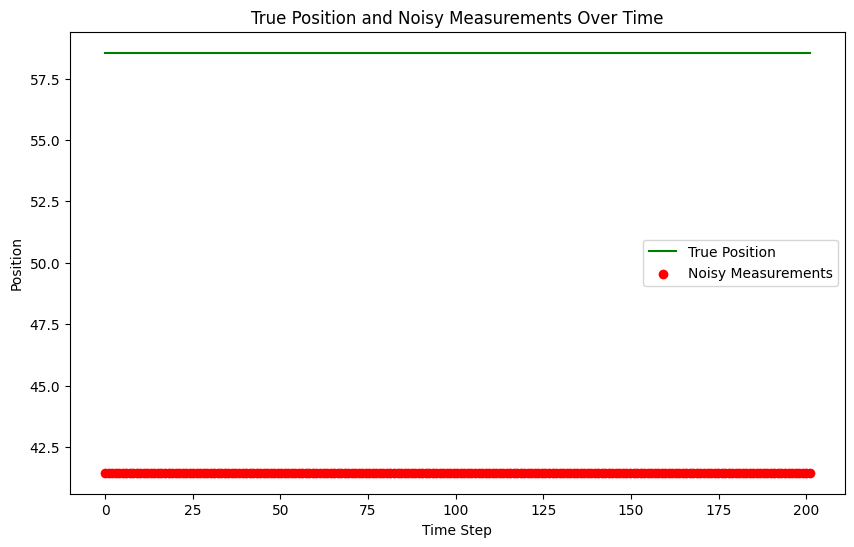

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Set the random seed for reproducibility
np.random.seed(42)

# Simulate the ground truth position of the object
true_velocity = 0.5  # units per time step
num_steps = len(poll_dataset) - 1
time_steps = np.linspace(0, num_steps, num_steps)
true_positions_m = [poll_dataset_t2.loc[0, "Macron (LREM)"]] * num_steps
true_positions_lp = [poll_dataset_t2.loc[0, "Le Pen (RN)"]] * num_steps

# Simulate the measurements with noise
measurements = poll_dataset.loc[1:, "Macron (LREM)"][::-1].reset_index(drop=True)

# Plot the true positions and the noisy measurements
plt.figure(figsize=(10, 6))
plt.plot(time_steps, true_positions_m, label="True Position", color="green")
plt.scatter(
    time_steps, true_positions_lp, label="Noisy Measurements", color="red", marker="o"
)

plt.xlabel("Time Step")
plt.ylabel("Position")
plt.title("True Position and Noisy Measurements Over Time")
plt.legend()
plt.show()

/tmp/ipykernel_3143/3934574219.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  estimated_positions_m[t] = kf.x[0]
/tmp/ipykernel_3143/3934574219.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  estimated_positions_lp[t] = kf.x[1]


NameError: name 'noisy_measurements' is not defined

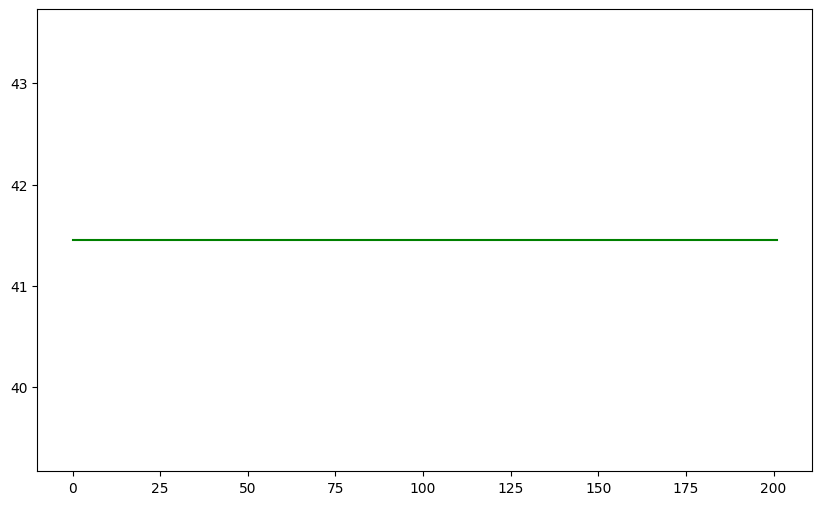

In [ ]:
# Kalman Filter Initialization
F = np.array([[1, 1], [0, 1]])  # State transition matrix
B = np.array([[0], [0]])  # No control input
u = np.array([[0]])  # No control input
H = np.array([[1, 0]])  # Measurement function
Q = np.array([[1, 0], [0, 3]])  # Process noise covariance
R = np.array([[10**2]])  # Measurement noise covariance
x0 = np.array([[50], [50]])  # Initial state estimate
P0 = np.array([[1, 0], [0, 1]])  # Initial estimate covariance

kf = KalmanFilter(F, B, u, H, Q, R, x0, P0)

# Allocate space for estimated positions and velocities
estimated_positions_m = np.zeros(num_steps)
estimated_positions_lp = np.zeros(num_steps)

# Kalman Filter Loop
for t in range(1, num_steps):
    # Predict
    kf.predict()

    # Update
    measurement = np.array(measurements[t])
    kf.update(measurement)

    # Store the filtered position
    estimated_positions_m[t] = kf.x[0]
    estimated_positions_lp[t] = kf.x[1]

# Plot the true positions, noisy measurements, and the Kalman filter estimates
plt.figure(figsize=(10, 6))
plt.plot(time_steps, true_positions_p, label="True Position", color="green")
plt.scatter(
    time_steps, noisy_measurements, label="Noisy Measurements", color="red", marker="o"
)
plt.plot(time_steps, estimated_positions, label="Kalman Filter Estimate", color="blue")

plt.xlabel("Time Step")
plt.ylabel("Position")
plt.title("Kalman Filter Estimation Over Time")
plt.legend()
plt.show()